<a href="https://colab.research.google.com/github/marcojrr/AtividadePosTechFIAP_Fase01/blob/main/techChallengeFase1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np

# Contexto
O crescimento acelerado do e-commerce trouxe ganhos de escala para a empresa, mas também evidenciou desafios na experiência do cliente, especialmente pela grande variação do NPS entre diferentes perfis. Mesmo com indicadores operacionais semelhantes, alguns clientes se tornam promotores e outros detratores, o que levanta a necessidade de entender quais fatores realmente impactam a satisfação. Como o NPS é coletado apenas ao final da jornada, a empresa tem pouca capacidade de agir de forma preventiva, tornando essencial transformar dados operacionais em insights que permitam antecipar problemas e melhorar a experiência do cliente.

# To do
1. Nos traga a resposta para as seguintes
perguntas de negócio:
- Qual problema de negócio está sendo resolvido?
- Por que o NPS é importante para um e-commerce?
- Quais áreas poderiam se beneficiar desses insights? Exemplos:
logística, atendimento, pricing, produto etc.

Além do entendimento do negócio, inclua uma reflexão (não precisa de dados
externos obrigatórios):

Como o NPS impacta:
- Recompra;
- Boca a boca;
- Market share em e-commerce.

Quais indicadores de mercado poderiam complementar essa análise?
Exemplos: benchmarks de NPS, SLA logístico, concorrência.

---
2. Definição da Target: qual é o alvo desse problema de negócio? Nessa segunda
etapa queremos uma avaliação de entendimento conceitual, não técnico.
- Qual variável representa a satisfação do cliente?
- Por que ela foi escolhida?
- Em que momento da jornada essa informação é coletada?
- Existe algum risco de usar essa variável de forma inadequada?
---
3. Análise Exploratória dos Dados (EDA): realize uma análise exploratória com
foco em negócio, não só estatística. Responda:
- Quais fatores parecem mais críticos para a satisfação?
- O que mais gera detratores?
- Existe algum “ponto de ruptura” na experiência do cliente?
- Que tipo de cliente tende a ter NPS mais alto ou mais baixo?
Imagine que você está explicando isso para um(a) gerente de operações
que não entende estatística.
---
4. Como forma de preparação para as próximas fases do curso, este desafio
propõe uma reflexão prática sobre como a Ciência de Dados pode ser
utilizada para antecipar a satisfação do cliente.
A partir da dor de negócio apresentada neste case, reflita sobre como um
modelo preditivo poderia apoiar a empresa a prever o NPS antes da aplicação da
pesquisa. Considere diferentes abordagens possíveis, como:
- Um modelo de regressão, para estimar a nota de NPS em uma escala
contínua;
- Um modelo de classificação, para categorizar clientes, por exemplo, em
satisfeitos e insatisfeitos.
Descreva qual estratégia você adotaria para resolver esse problema utilizando
dados e Inteligência Artificial, justificando suas escolhas do ponto de vista técnico e
de negócio.
Caso opte por implementar a solução, apresente uma proposta de modelo
aplicada em Python, explicando de forma clara:
- A definição da variável alvo;
- A seleção e preparação das variáveis de entrada;
- A lógica de separação dos dados (quando aplicável);
- A escolha do modelo;
- A forma de avaliação dos resultados;
- E como essa solução poderia ser utilizada na prática pela empresa





# Lendo base de dados

## Base de dados NPS
- Endereço: "https://raw.githubusercontent.com/AnaRaquelCafe/POSTECH_AI_SCIENTIST/main/Base%20de%20dados%20Tech%20Challenge/desafio_nps_fase_1.csv"

## Dicionário de dados
- customer_id: Identificador único do cliente.
- order_id: Identificador único do pedido.
- customer_age: Idade do cliente.
- customer_region: Região geográfica do cliente.
- customer_tenure_months: Tempo de relacionamento do cliente com a
empresa (em meses).
- order_value: Valor total do pedido.
- items_quantity: Quantidade de itens no pedido.
- discount_value: Valor de desconto aplicado ao pedido.
- payment_installments: Número de parcelas do pagamento.
- delivery_time_days: Tempo total de entrega (em dias).
- delivery_delay_days: Quantidade de dias de atraso na entrega.
- freight_value: Valor do frete.
- delivery_attempts: Número de tentativas de entrega.
- customer_service_contacts: Número de contatos do cliente com o
atendimento.
- resolution_time_days: Tempo para resolução de problemas (em dias).
Página 6 de 9
- complaints_count: Número de reclamações registradas pelo cliente.
- repeat_purchase_30d: Indica se houve recompra em até 30 dias após o
pedido (0 = não, 1 = sim).
- csat_internal_score: Score interno de satisfação do cliente.
- nps_score: Nota de satisfação do cliente (NPS), variando de 0 a 10, coletada
após a experiência de compra.

In [2]:
# leitura da base
path = "https://raw.githubusercontent.com/AnaRaquelCafe/POSTECH_AI_SCIENTIST/main/Base%20de%20dados%20Tech%20Challenge/desafio_nps_fase_1.csv"
df_nps = pd.read_csv(path)

# Exploração dos dados

In [3]:
df_nps.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [4]:
df_nps.tail()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
2495,2496,51,Sul,96,52496,615.81,6,11.41,2,14,3,28.96,2,1,2,3.7,0,3,4.3
2496,2497,37,Sul,89,52497,73.03,1,36.44,3,12,2,27.42,2,2,7,3.7,0,4,2.5
2497,2498,19,Sudeste,98,52498,522.78,1,4.84,9,2,2,38.94,1,1,1,7.4,0,3,6.2
2498,2499,41,Sul,51,52499,55.87,2,2.11,2,14,5,29.10,3,3,0,2.3,0,5,1.7
2499,2500,35,Nordeste,109,52500,420.94,1,16.51,4,11,1,34.16,3,1,0,10.0,1,2,7.6


In [5]:
# tamanho do df
print(f'tamanho do nosso dataset (Linhas, Colunas): {df_nps.shape}')

tamanho do nosso dataset (Linhas, Colunas): (2500, 19)


In [6]:
# verificando valores nulos cada coluna
df_nps.isnull().sum()

,0
customer_id,0
customer_age,0
customer_region,0
customer_tenure_months,0
order_id,0
order_value,0
items_quantity,0
discount_value,0
payment_installments,0
delivery_time_days,0


### Não existem dados nulos do dataFrame.

In [7]:
df_nps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   object 
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64

In [8]:
# verificando valores unicos
df_nps.nunique()

,0
customer_id,2500
customer_age,52
customer_region,5
customer_tenure_months,119
order_id,2500
order_value,2457
items_quantity,6
discount_value,2050
payment_installments,11
delivery_time_days,13


## Criando faixa de score

In [9]:
def classe_nps(score):
  if score >= 9:
    return 'promotor'
  elif score >= 7:
    return 'neutro'
  else:
    return 'detrator'

df_nps['classe_nps'] = df_nps['nps_score'].apply(classe_nps)

In [10]:
df_nps.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,classe_nps
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5,detrator
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0,detrator
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5,detrator
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3,detrator
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9,detrator


In [11]:
df_nps['classe_nps'].value_counts()


,count
classe_nps,
detrator,2109
neutro,281
promotor,110


In [12]:
df_nps['classe_nps'].value_counts()/2500 * 100

,count
classe_nps,
detrator,84.36
neutro,11.24
promotor,4.40


### Criando uma faixa de score com o 'nps_score', constatamos que mais de 84% dos clientes são detratores

# Análise descritiva

In [13]:
df_nps.describe()

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00000,2500.000000,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,1250.50000,43.396000,61.322400,51250.50000,434.259740,3.470800,29.745620,6.004000,8.022000,2.187200,38.217016,2.005600,1.519600,5.485600,4.378600,0.087200,4.150400,2.941600
std,721.83216,14.888487,34.478729,721.83216,289.772497,1.687331,29.225603,3.159743,3.770411,1.454442,12.076074,0.815497,1.231512,3.458002,2.510229,0.282184,1.784223,2.378957
min,1.00000,18.000000,1.000000,50001.00000,7.760000,1.000000,0.020000,1.000000,2.000000,0.000000,2.620000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,625.75000,31.000000,31.000000,50625.75000,220.245000,2.000000,8.885000,3.000000,5.000000,1.000000,29.927500,1.000000,1.000000,2.000000,2.600000,0.000000,3.000000,0.700000
50%,1250.50000,43.000000,62.000000,51250.50000,375.515000,3.000000,20.935000,6.000000,8.000000,2.000000,38.500000,2.000000,1.000000,6.000000,4.400000,0.000000,4.000000,2.800000
75%,1875.25000,56.000000,91.000000,51875.25000,577.290000,5.000000,40.832500,9.000000,11.000000,3.000000,46.270000,3.000000,2.000000,8.000000,6.100000,0.000000,5.000000,4.800000
max,2500.00000,69.000000,119.000000,52500.00000,1983.810000,6.000000,230.330000,11.000000,14.000000,8.000000,76.130000,3.000000,7.000000,11.000000,10.000000,1.000000,11.000000,10.000000


In [25]:
lista_variaveis =  [
'customer_age',
'order_value',
'delivery_time_days',
'delivery_delay_days',
'csat_internal_score',
'delivery_attempts',
'complaints_count',
'customer_service_contacts',
'resolution_time_days',
'discount_value',
'nps_score'
]

df_dist = df_nps[lista_variaveis]


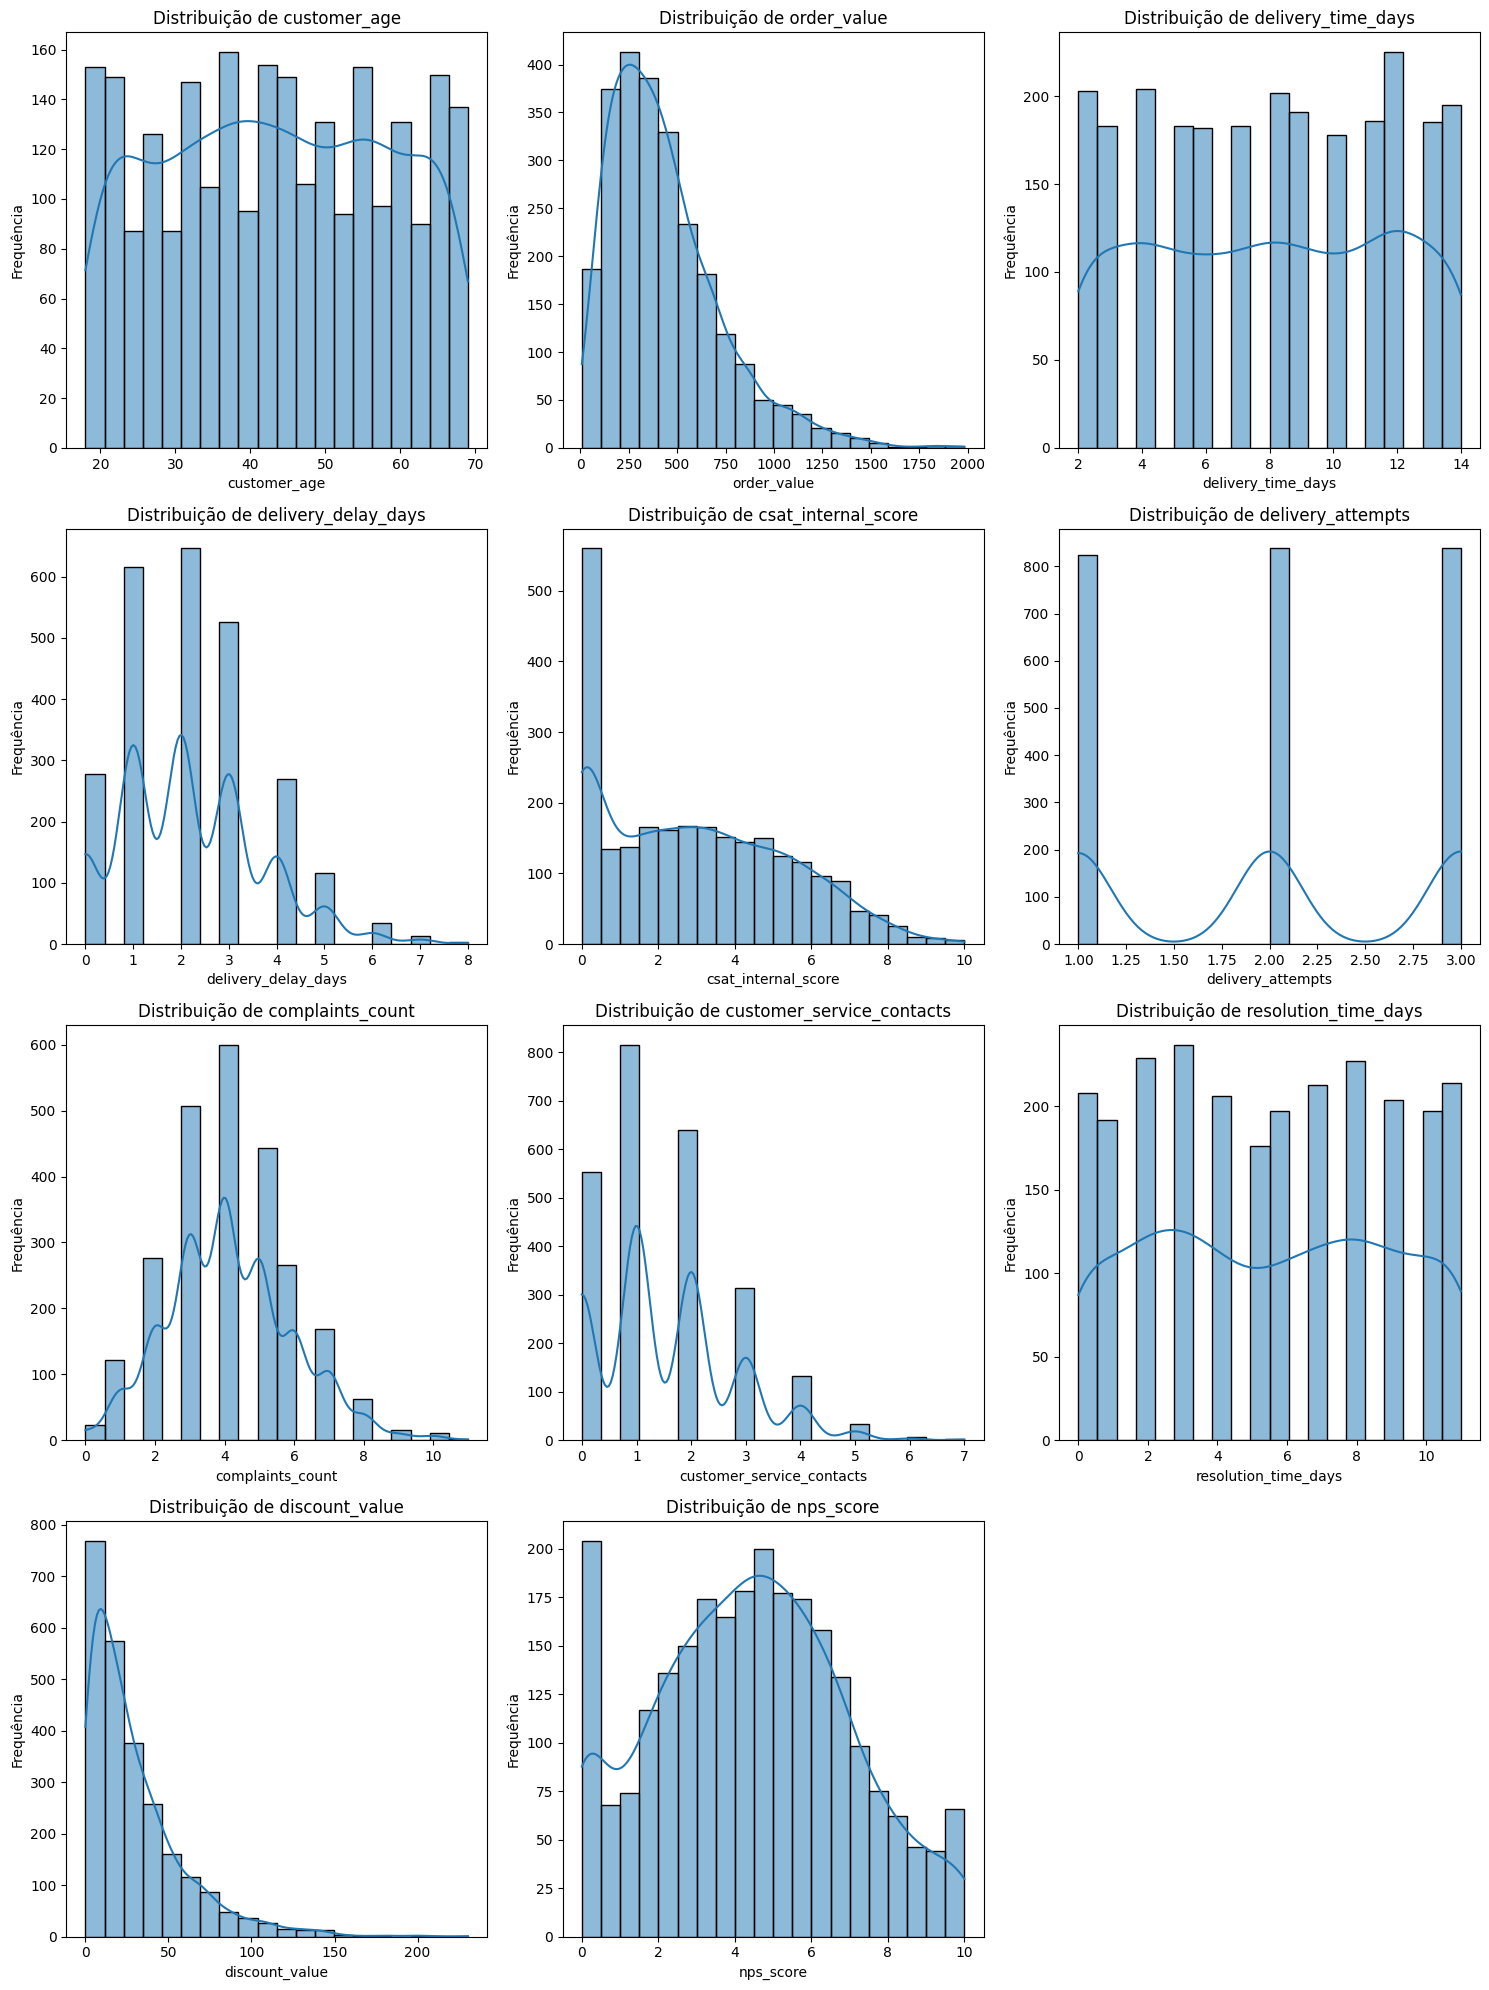

In [26]:
num_cols = len(df_dist.columns)
num_rows = (num_cols + 2) // 3 # Adjust rows based on 3 columns per row

plt.figure(figsize=(15, num_rows * 5))

for i, column in enumerate(df_dist.columns):
    plt.subplot(num_rows, 3, i + 1)
    sns.histplot(df_dist[column], bins=20, kde=True)
    plt.title(f'Distribuição de {column}')
    plt.xlabel(column)
    plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

### Análisando algumas distribuições
- Nossa base de clientes tem idade diversa, com média de 43 anos;
- O valor dos pedidos tem distribuição concentrada a esquerda, 75% dos valores estão abaixo de 578 reais;
- maioria dos clientes estão com score interno igual a 0;
- numero de reclamações medio é de 4 por cliente

In [27]:
outras_variaveis =  [
'csat_internal_score',
'customer_age',
'order_value',
'delivery_time_days',
'delivery_delay_days',
'delivery_attempts',
'complaints_count',
'customer_service_contacts',
'resolution_time_days',
'discount_value',
'nps_score'
]

df_score_comp = df_nps[outras_variaveis]


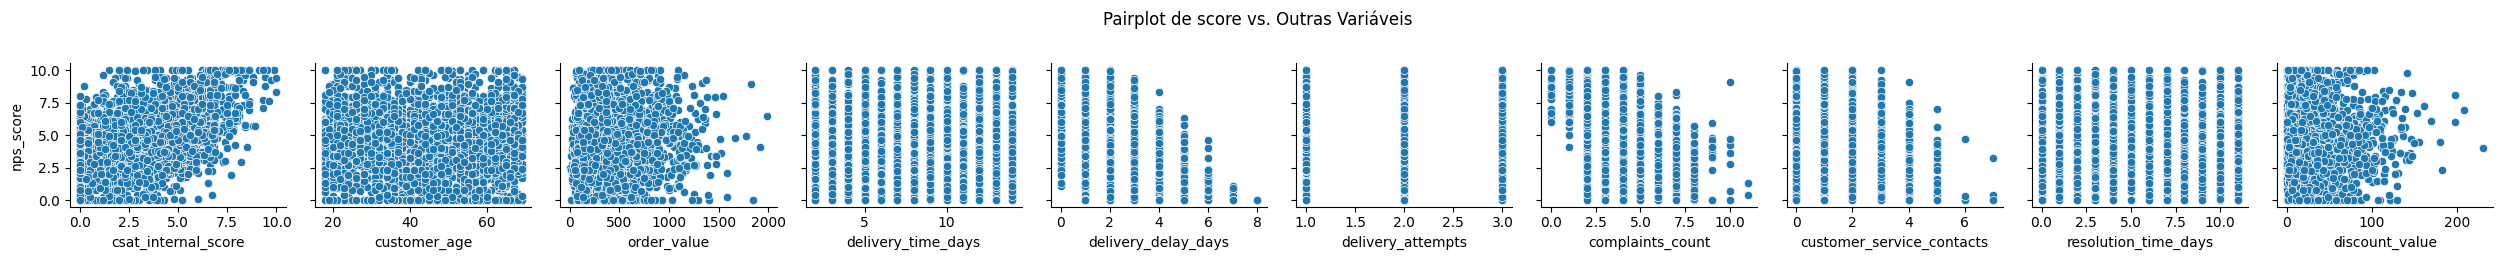

In [28]:
sns.pairplot(df_score_comp, y_vars=['nps_score'], x_vars=df_score_comp.drop('nps_score', axis=1), kind='scatter')
plt.suptitle(f'Pairplot de score vs. Outras Variáveis', y=1.02)
plt.tight_layout()
plt.show()

### As maiores avaliações de NPS estão concentradas em pedidos que tiveram poucos atrasos



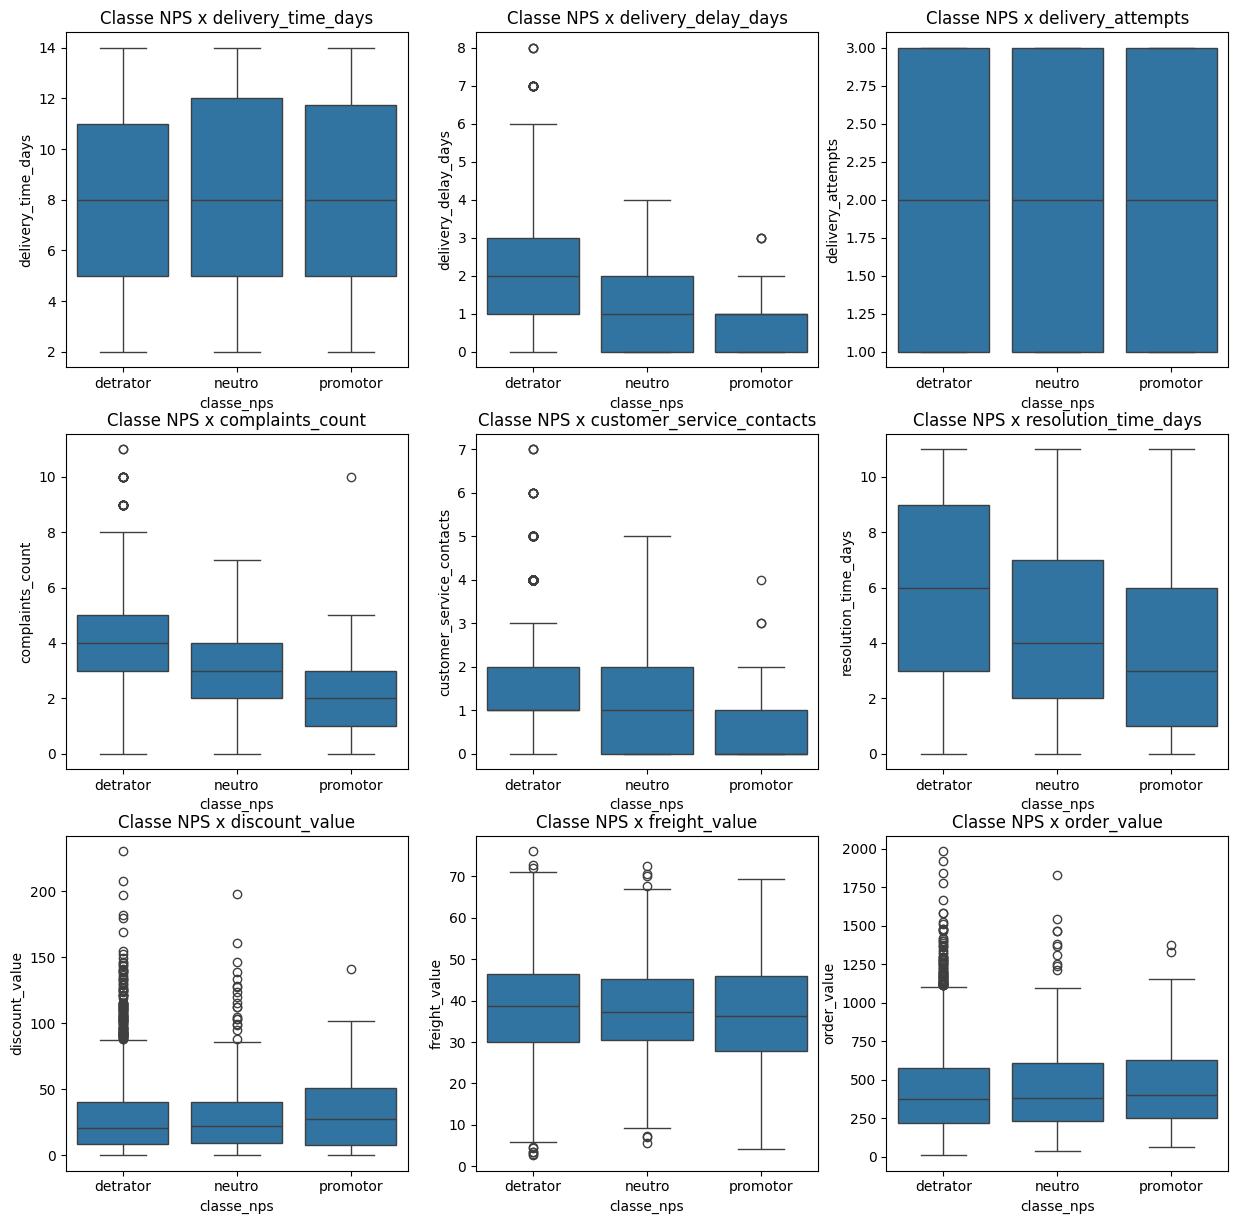

In [31]:
variaveis =  [
  'delivery_time_days',
  'delivery_delay_days',
  'delivery_attempts',
  'complaints_count',
  'customer_service_contacts',
  'resolution_time_days',
  'discount_value',
  'freight_value',
  'order_value'
]

df_box = df_nps[['classe_nps'] + variaveis]

num_cols = len(df_dist.columns)
num_rows = (num_cols + 2) // 3

plt.figure(figsize=(15, num_rows * 5))

for i, column in enumerate(variaveis):
    plt.subplot(num_rows, 3, i + 1)
    sns.boxplot(x='classe_nps', y=column, data=df_box)
    plt.title(f'Classe NPS x {column}')
    plt.xlabel('classe_nps')
    plt.ylabel(column)

- Promotores são, em maioria, aqueles que tem seus produtos entregues dentro do prazo estipulado e que tem seus problemas resolvidos em um período mais rápido;

- Já os detratores, observamos que há uma concentração em atrasos na entrega de um a três dias. Adicionalmente, os detratores são os que costumam ter mais registros de reclamações;

- Observamos também que, os detratores possuem muitos outliers quando olhamos para a variável de valor da compra. Isso pode indicar que são mais exigentes com o serviço prestado por estarem pagando um valor mais alto;

- Dias para resolução altos tambem são causadores para clientes se tornarem detratores.

- promotores voltam a comprar e detratores não voltam a comprar. Se estamos procurando aumentar a fidelização dos clientes e aumentar receita esse é o kpi

<Axes: xlabel='classe_nps', ylabel='csat_internal_score'>

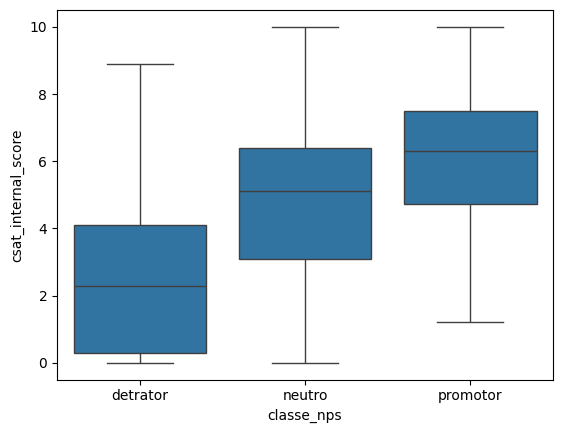

In [ ]:
sns.boxplot(x='classe_nps', y='csat_internal_score', data=df_nps)

- ordenação ok

<Axes: xlabel='customer_region', ylabel='count'>

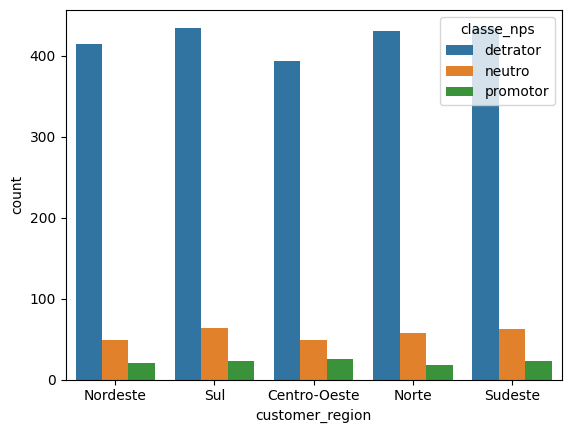

In [ ]:
# analisando regiao
sns.countplot(x='customer_region', hue='classe_nps', data=df_nps)

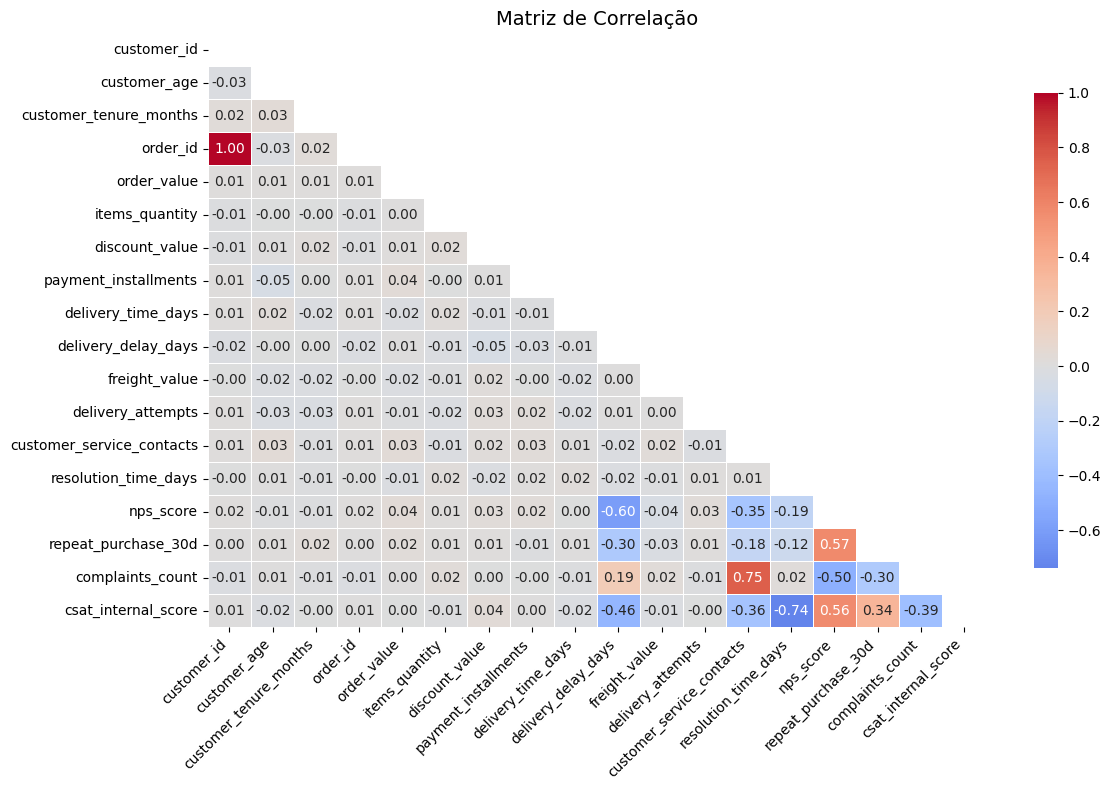

In [ ]:
corr = df_nps.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.title("Matriz de Correlação", fontsize=14)
plt.tight_layout()
plt.show()

<Axes: xlabel='classe_nps', ylabel='repeat_purchase_30d'>

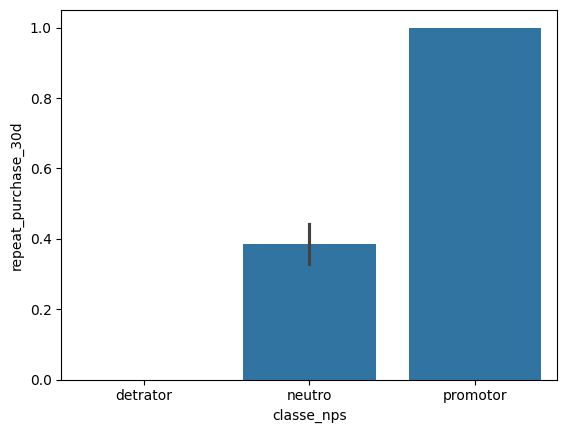

In [ ]:
#Verificando qual classe possui mais registros de recompra

sns.barplot(x='classe_nps', y='repeat_purchase_30d', data=df_nps)

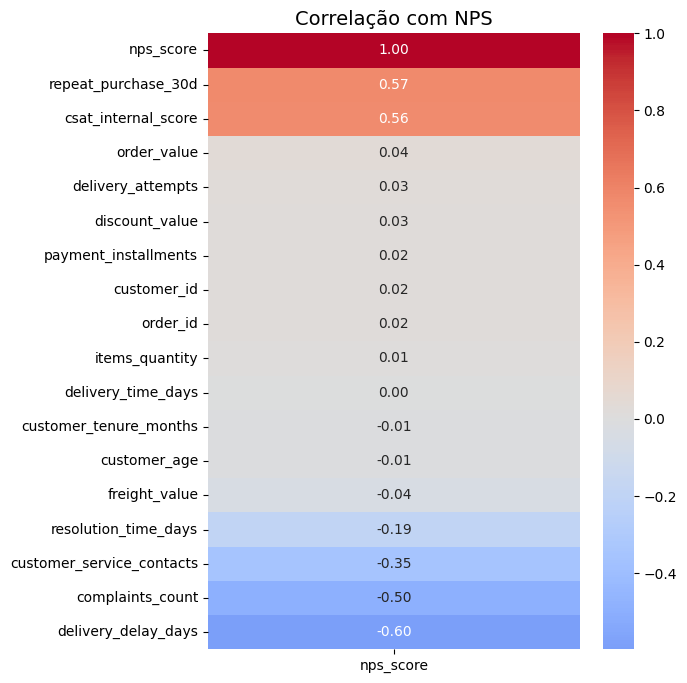

In [ ]:
corr_nps = df_nps.corr(numeric_only=True)[['nps_score']].sort_values(by='nps_score', ascending=False)

plt.figure(figsize=(6, 8))

sns.heatmap(
    corr_nps,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Correlação com NPS", fontsize=14)
plt.show()

### Observa-se que o atraso na entrega apresenta correlação negativa com a variável de NPS, indicando que, quanto maior o atraso, maiores são as chances de o cliente se tornar um detrator. Esse fator se mostra como o principal ponto de ruptura na experiência do cliente, contribuindo para a redução do NPS.